# Experiment 3: MuRIL -- Bangla+English Train -> Bangla Test
### Hope Speech Detection | Multilingual Training

**Model:** `google/muril-base-cased` (MuRIL)  
**Training Data:** Bangla (training portion) + English (full dataset)  
**Test Data:** Bangla only  
**Task:** Binary Classification -- Hope Speech vs. Non-Hope Speech  
**Supported file formats:** `.csv`, `.tsv`, `.txt`, `.xml`, `.ods`

## 1. Install Dependencies

In [1]:
%%capture
# Install all required packages.
# %%capture suppresses installation output to keep the notebook log clean.
!pip install transformers datasets scikit-learn pandas openpyxl odfpy \
             lxml seaborn matplotlib accelerate evaluate \
             tqdm scipy \
             emoji \
             xgboost


## 2. Import Libraries and Fix Random Seeds

In [2]:
import os
import re
import json
import random
import warnings
import unicodedata
import html

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.special import softmax as scipy_softmax

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_curve, auc
)

import torch
from torch.utils.data import Dataset
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback, TrainerCallback, set_seed,

)

# Suppress non-critical warnings to keep output readable.
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Global random seed.  Every stochastic component (Python, NumPy, PyTorch,
# cuDNN, and the Hugging Face Trainer) is fixed so that experimental results
# are exactly reproducible.  Record this value in the accompanying paper.
# ---------------------------------------------------------------------------
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic        = True
torch.backends.cudnn.benchmark            = False
# Disable TF32 on Ampere GPUs (A100, RTX 30xx) for full float32 reproducibility.
torch.backends.cuda.matmul.allow_tf32     = False
torch.backends.cudnn.allow_tf32           = False
os.environ["PYTHONHASHSEED"]              = str(SEED)
# Prevent tokenizer parallelism deadlocks when DataLoader forks workers.
os.environ["TOKENIZERS_PARALLELISM"]      = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Seed   : {SEED}  (fixed for reproducibility)")


Device : cuda
GPU    : Tesla T4
Seed   : 42  (fixed for reproducibility)


## 3. Universal File Loader
Supports: `.csv`, `.tsv`, `.txt`, `.xml`, `.ods`

In [3]:
# ---------------------------------------------------------------------------
# Universal file loader.
# Accepts .csv, .tsv, .txt, .xml, and .ods files.
# Returns a DataFrame with exactly two columns: ["text", "label"].
# Labels are normalised to integers: 0 = Non-Hope Speech, 1 = Hope Speech.
# ---------------------------------------------------------------------------

def _normalize_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map string or numeric labels to binary integers.

    Mapping rules
    -------------
    - If all values are already in {0, 1, 0.0, 1.0}, cast directly to int.
    - Otherwise, map recognised hope-speech tokens to 1; everything else to 0.
      Recognised hope tokens: "hope_speech", "hope", "positive", "pos", "1",
      "hope speech".

    Parameters
    ----------
    df : DataFrame with a "label" column of arbitrary string or numeric values.

    Returns
    -------
    The same DataFrame with "label" overwritten as integer (0 or 1).
    """
    unique = df["label"].astype(str).str.lower().str.strip().unique()
    if set(unique).issubset({"0", "1", "0.0", "1.0"}):
        df["label"] = df["label"].astype(float).astype(int)
        return df
    hope_tokens = {"hope_speech", "hope", "positive", "pos", "1", "hope speech"}
    label_map   = {lbl: (1 if lbl in hope_tokens else 0) for lbl in unique}
    df["label"] = (
        df["label"].astype(str).str.lower().str.strip()
        .map(label_map).astype(int)
    )
    return df


def load_any_file(
    filepath:  str,
    text_col:  str = None,
    label_col: str = None
) -> pd.DataFrame:
    """
    Load a dataset file and return a normalised DataFrame with columns
    ["text", "label"].

    Parameters
    ----------
    filepath  : path to the dataset file
    text_col  : column name for the text field (used when .ods files carry
                named headers; ignored otherwise)
    label_col : column name for the label field (used when .ods files carry
                named headers; ignored otherwise)

    Supported formats
    -----------------
    .csv  -- auto-detects comma vs semicolon separator via a 2 KB header probe
    .tsv  -- tab-separated
    .txt  -- one (text, label) pair per line, tab- or semicolon-delimited
    .xml  -- elements with <text>/<comment>/<sentence> and
             <label>/<class>/<category> child nodes
    .ods  -- OpenDocument Spreadsheet; first two columns used by default

    Returns
    -------
    DataFrame with columns ["text", "label"], integer labels, no empty rows.

    Raises
    ------
    ValueError : if the file extension is not among the supported formats.
    """
    ext = Path(filepath).suffix.lower()
    print(f"Loading file: {filepath}  [format: {ext}]")

    if ext == ".csv":
        # Probe the first 2 KB to choose the correct delimiter.
        with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
            sample = fh.read(2048)
        sep = ";" if sample.count(";") > sample.count(",") else ","
        df = pd.read_csv(
            filepath, sep=sep, header=None,
            on_bad_lines="skip", engine="python",
            encoding="utf-8", encoding_errors="replace"
        )

    elif ext == ".tsv":
        df = pd.read_csv(
            filepath, sep="\t", header=None,
            on_bad_lines="skip", engine="python",
            encoding="utf-8", encoding_errors="replace"
        )

    elif ext == ".txt":
        rows = []
        with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                if "\t" in line:
                    parts = line.rsplit("\t", 1)
                elif ";" in line:
                    parts = line.rsplit(";", 1)
                else:
                    continue
                rows.append(parts)
        df = pd.DataFrame(rows)

    elif ext == ".xml":
        tree = ET.parse(filepath)
        root = tree.getroot()
        rows = []
        for item in root.iter():
            text_node  = (item.find("text")  or item.find("comment")
                          or item.find("sentence"))
            label_node = (item.find("label") or item.find("class")
                          or item.find("category"))
            if text_node is not None and label_node is not None:
                rows.append([text_node.text, label_node.text])
        df = pd.DataFrame(rows)

    elif ext == ".ods":
        df = pd.read_excel(filepath, engine="odf")
        if not all(isinstance(c, int) for c in df.columns):
            df.columns = [str(c).strip() for c in df.columns]
            if text_col and label_col:
                df = df.rename(columns={text_col: "text", label_col: "label"})
            else:
                col_lower = {c.lower(): c for c in df.columns}
                text_key  = next(
                    (col_lower[k] for k in col_lower
                     if any(w in k for w in ["comment", "text", "sentence"])),
                    df.columns[0]
                )
                label_key = next(
                    (col_lower[k] for k in col_lower
                     if any(w in k for w in ["label", "class", "pred"])),
                    df.columns[1]
                )
                df = df.rename(columns={text_key: "text", label_key: "label"})
        df = df[["text", "label"]].dropna()
        df = _normalize_labels(df)
        print(f"Loaded {len(df)} rows | Labels: {df['label'].value_counts().to_dict()}")
        return df

    else:
        raise ValueError(
            f"Unsupported format: {ext}.  "
            f"Supported extensions: .csv  .tsv  .txt  .xml  .ods"
        )

    df = df.iloc[:, :2].copy()
    df.columns = ["text", "label"]
    df = df.dropna(subset=["text", "label"])
    df["text"]  = df["text"].astype(str).str.strip()
    df["label"] = df["label"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = _normalize_labels(df)
    print(f"Loaded {len(df)} rows | Labels: {df['label'].value_counts().to_dict()}")
    return df


print("File loader defined.")


File loader defined.


## 4. Upload Datasets

Upload **two** files:
1. **Bangla dataset** -- used for both training and testing
2. **English dataset** -- used for training only

In [4]:
from google.colab import files

print("Upload the BANGLA dataset (used for both training and testing):")
up1         = files.upload()
BANGLA_FILE = list(up1.keys())[0]
print(f"Bangla file: {BANGLA_FILE}")

print("\nUpload the ENGLISH dataset (used for training only):")
up2          = files.upload()
ENGLISH_FILE = list(up2.keys())[0]
print(f"English file: {ENGLISH_FILE}")


Upload the BANGLA dataset (used for both training and testing):


Saving bangla_bonghope.ods to bangla_bonghope.ods
Bangla file: bangla_bonghope.ods

Upload the ENGLISH dataset (used for training only):


Saving english_hopeedi.csv to english_hopeedi.csv
English file: english_hopeedi.csv


## Dataset Information

> **Fill in before submission.**

| Field | Value |
|---|---|
| **Dataset name** | *BongHope / HopeEDI* |
| **Source / DOI** | *https://doi.org/10.21203/RS.3.RS-2819284/V1 / https://aclanthology.org/2020.peoples-1.5/*|
| **License** | *Creative Commons Attribution 4.0 International License* |
| **Language(s)** | Bangla (`bn`) / English (`en`) |
| **Total samples** | *4,257 / 28,451* |
| **Label schema** | `1` = Hope Speech · `0` = Non-Hope Speech |
| **Original class ratio** | *`1` = 1,608 · `0` = 2,649* . *`1.65:1`* / *`1` = 2,484 · 0 = 25,940 . `other's` = 27* . *`10.49:1`*  |

*Cite the dataset in the paper using the above DOI.*

## 5. Configuration

In [5]:
# ---------------------------------------------------------------------------
# Experiment 3 configuration.
# Hyperparameters were selected by grid search on the validation set:
#   - learning_rate over {2e-5, 1e-5, 5e-6}
#   - batch_size over {8, 16}
# All other values reflect standard practice for BERT fine-tuning on small
# datasets.
# ---------------------------------------------------------------------------
MODEL_NAME    = "google/muril-base-cased"
MAX_LEN       = 128
BATCH_SIZE    = 16
NUM_EPOCHS    = 4
LEARNING_RATE = 1e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
TEST_SIZE     = 0.15   # 15 % held-out from Bangla for testing
VAL_SIZE      = 0.15   # 15 % of the post-split training pool for validation
NUM_LABELS    = 2
OUTPUT_DIR    = "./mbert_banglaen_bangla"

SUPTITLE     = "MuRIL | Bangla+English -> Bangla"
RESULT_TITLE = "MuRIL | Bangla+English Train -> Bangla Test"
CM_CMAP      = "Purples"
CM_TITLE     = "MuRIL | Bangla+English -> Bangla"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Config  |  Model: {MODEL_NAME}  |  MaxLen: {MAX_LEN}  |  Batch: {BATCH_SIZE}")


Config  |  Model: google/muril-base-cased  |  MaxLen: 128  |  Batch: 16


## 6. Data Preprocessing

Preprocessing function defined here. Applied to the **full dataset** in Section 7, **before** any split — following the pipeline: Raw → Preprocess → Split.

**Cleaning steps (inside `preprocess_text`):**
1. HTML entity decoding
2. Residual HTML/XML tag removal
3. NFC Unicode normalisation (critical for Bangla — multiple byte encodings unified)
4. URL removal
5. @-mention removal
6. Hashtag cleaning (`#hope_speech` → `hope speech`)
7. Repeated punctuation collapsing (`!!!` → `!`)
8. Invisible Unicode removal (ZWJ, ZWNJ, soft-hyphen — Bangla social media specific)
9. Elongation normalisation (`"পারবোওওও"` → `"পারবোও"`, `"yesssss"` → `"yess"`)
10. Emoji removal
11. Final whitespace normalisation

**Filtering steps (inside `apply_preprocessing`):**
1. NaN drop — rows with missing text or label
2. Label validity — keep only `{0, 1}` labels
3. Empty text drop — rows empty after cleaning
4. Minimum word count — fewer than 3 tokens removed
5. Minimum character length — fewer than 10 characters removed
6. Maximum character length — more than 512 characters removed (spam / data errors)
7. Script validation — skipped for mixed BN+EN dataset (both scripts are valid)
8. Exact duplicate removal — identical (text, label) pairs deduplicated
9. Annotation conflict removal — same text with conflicting labels removed


In [6]:
# ---------------------------------------------------------------------------
# Text preprocessing pipeline.
# Applied to the FULL dataset before splitting.
# The ordering of steps is intentional: HTML decoding must
# precede all regex-based cleaning to avoid false matches on entity sequences.
# ---------------------------------------------------------------------------
import emoji   # pip install emoji  (already in requirements)

def preprocess_text(text: str) -> str:
    """
    Clean a single raw text string.

    Steps
    -----
    1. Decode HTML entities (&amp; -> &, <br> -> space, etc.)
    2. Strip residual HTML/XML tags.
    3. NFC Unicode normalisation -- unifies Bangla characters that have
       multiple valid byte-level encodings into a single canonical form.
    4. Remove URLs (http:// and https://).
    5. Remove @-mention tokens.
    6. Clean hashtags: #hope_speech -> hope speech.
    7. Collapse repeated punctuation runs (e.g., !!! -> !).
    8. Remove invisible Unicode characters (ZWJ, ZWNJ, soft-hyphen, BOM).
       These cause the same Bangla word to receive different tokenizer
       representations and must be stripped before vocabulary is built.
    9. Elongation normalisation -- collapse 3+ repeated characters to 2
       (e.g., "পারবোওওও" -> "পারবোও", "yesssss" -> "yess").
       Preserves intentional doubles while reducing vocabulary noise.
    10. Emoji removal -- all Unicode emoji replaced with a space so they
        do not become stray tokens or invisible garbage downstream.
    11. Final whitespace normalisation and strip.

    Parameters
    ----------
    text : raw input string

    Returns
    -------
    Cleaned string, or empty string when the input is not a str instance.
    """
    if not isinstance(text, str):
        return ""

    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", lambda m: m.group(1).replace("_", " "), text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)
    text = re.sub(r"[\.]{2,}", ".", text)
    # 9. Remove Zero-Width Joiners / Non-Joiners and other invisible Unicode
    #    characters. These are common in Bangla social-media text and cause
    #    the same word to receive different tokenizer representations.
    text = re.sub(r"[​-‏‪-‮⁠﻿­]", "", text)
    # 10. Elongation normalisation: collapse runs of 3+ identical characters
    #     to 2 (preserves intentional doubles such as "আল্লাহ" while
    #     collapsing "পারবোওওও" → "পারবোও" and "yesssss" → "yess").
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # 11. Emoji removal: strip all Unicode emoji characters so they do not
    #     become stray whitespace or unknown tokens downstream.
    text = emoji.replace_emoji(text, replace=" ")
    # 12. Final whitespace normalisation after all substitutions.
    text = re.sub(r"\s+", " ", text).strip()
    return text


def has_bangla(text: str, threshold: float = 0.15) -> bool:
    """
    Return True when at least `threshold` fraction of characters fall
    inside the Unicode Bangla block (U+0980–U+09FF).
    More reliable than langdetect for short social-media texts.
    """
    if not text:
        return False
    bangla_chars = sum(1 for c in text if '\u0980' <= c <= '\u09FF')
    return (bangla_chars / len(text)) >= threshold




def has_latin(text: str, threshold: float = 0.3) -> bool:
    """
    Return True when at least `threshold` fraction of characters fall
    inside Basic Latin / Latin Extended Unicode blocks (U+0000-U+024F).
    Used to filter English-dominant texts.
    More reliable than langdetect for short social-media texts.
    """
    if not isinstance(text, str) or len(text) == 0:
        return False
    latin_chars = sum(
        1 for ch in text
        if ch.isalpha() and ord(ch) <= 0x024F
    )
    return (latin_chars / len(text)) >= threshold


def apply_preprocessing(
    df: pd.DataFrame,
    min_words: int  = 3,
    min_chars: int  = 10,
    max_chars: int  = 512,
    script_check = None,            # "bangla" | "latin" | None — None for mixed BN+EN
    script_threshold: float = 0.15,
) -> pd.DataFrame:
    """
    Apply preprocess_text to every row, then remove low-quality rows.

    Filtering steps
    ---------------
    1.  Drop NaN values in 'text' or 'label' columns.
    2.  Drop rows whose label is not in {0, 1}.
    3.  Apply preprocess_text to the 'text' column.
    4.  Drop rows whose text is empty after cleaning.
    5.  Drop rows with fewer than min_words whitespace-delimited tokens.
    6.  Drop rows shorter than min_chars characters.
    7.  Drop rows longer than max_chars characters (likely spam / data errors).
    8.  Script validation: drop rows that do not meet the expected script
        ratio (Bangla Unicode block >= script_threshold fraction).
    9.  Drop exact duplicates (identical text AND label pair).
    10. Detect and remove annotation conflicts (same text, different labels).

    Parameters
    ----------
    df               : DataFrame with columns ['text', 'label']
    min_words        : minimum token count threshold (default 3)
    min_chars        : minimum character count (default 10)
    max_chars        : maximum character count (default 512)
    script_check     : None skips script validation (used for mixed BN+EN datasets)
    script_threshold : minimum fraction of Bangla characters (default 0.15)

    Returns
    -------
    Cleaned DataFrame with a contiguous integer index and a printed report.
    """
    df = df.copy()
    n_raw = len(df)

    # 1. Drop NaN
    df = df.dropna(subset=["text", "label"])
    n_after_nan = len(df)

    # 2. Label validity
    df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0, 1])].reset_index(drop=True)
    n_after_label = len(df)

    # 3. Apply text cleaning
    df["text"] = df["text"].apply(preprocess_text)

    # 4. Empty text
    df = df[df["text"].str.strip() != ""]
    n_after_empty = len(df)

    # 5. Min word count
    df = df[df["text"].apply(lambda t: len(t.split()) >= min_words)]
    n_after_words = len(df)

    # 6. Min character length
    df = df[df["text"].str.len() >= min_chars]
    n_after_minchar = len(df)

    # 7. Max character length
    df = df[df["text"].str.len() <= max_chars]
    n_after_maxchar = len(df)

    # 8. Script validation
    if script_check == "bangla":
        df = df[df["text"].apply(lambda t: has_bangla(t, script_threshold))]
    elif script_check == "latin":
        df = df[df["text"].apply(lambda t: has_latin(t, script_threshold))]
    n_after_script = len(df)

    # 9. Exact duplicate removal
    n_before_dedup = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    n_after_dedup = len(df)

    # 10. Annotation conflict removal
    conflict_mask  = df.groupby("text")["label"].transform("nunique") > 1
    n_conflicts    = conflict_mask.sum()
    df = df[~conflict_mask].reset_index(drop=True)
    n_final = len(df)

    # ── Report ───────────────────────────────────────────────────────────────
    print("=" * 60)
    print("Preprocessing & Filtering Report")
    print("=" * 60)
    print(f"  Raw rows                   : {n_raw}")
    print(f"  After NaN drop             : {n_after_nan}  (-{n_raw - n_after_nan})")
    print(f"  After label validity       : {n_after_label}  (-{n_after_nan - n_after_label})")
    print(f"  After empty text drop      : {n_after_empty}  (-{n_after_label - n_after_empty})")
    print(f"  After min-word filter      : {n_after_words}  (-{n_after_empty - n_after_words})")
    print(f"  After min-char filter      : {n_after_minchar}  (-{n_after_words - n_after_minchar})")
    print(f"  After max-char filter      : {n_after_maxchar}  (-{n_after_minchar - n_after_maxchar})")
    print(f"  After script validation    : {n_after_script}  (-{n_after_maxchar - n_after_script})")
    print(f"  After exact-dedup          : {n_after_dedup}  (-{n_before_dedup - n_after_dedup})")
    print(f"  After conflict removal     : {n_final}  (-{n_conflicts} conflict rows)")
    print(f"  Final rows retained        : {n_final}")
    print(f"  Label distribution         : {df['label'].value_counts().sort_index().to_dict()}")
    print("=" * 60)
    return df


print("Preprocessing functions defined.")


Preprocessing functions defined.


## 7. Load, Preprocess and Explore Data

Preprocessing is applied to **both full datasets** before any split.
Pipeline: Raw → Preprocess → Split.

**Bangla (df_bn):**
- `df_test` — 15 % stratified hold-out; frozen for final evaluation.
- `df_val_bn` — 15 % stratified hold-out; real data; contributes to the combined early-stopping val set.
- `df_bn_trainval` — remaining 70 %; used as the training pool.

**English (df_en):**
- `df_en_val` — 15 % stratified hold-out; real data; contributes to the combined early-stopping val set.
- `df_en_train` — remaining 85 %; used as the training pool.

The combined early-stopping val set is `df_val = df_val_bn + df_en_val` (real data only).


Loading file: bangla_bonghope.ods  [format: .ods]
Loaded 4257 rows | Labels: {0: 2649, 1: 1608}
Loading file: english_hopeedi.csv  [format: .csv]
Loaded 28330 rows | Labels: {0: 25866, 1: 2464}
Preprocessing & Filtering Report
  Raw rows                   : 4257
  After NaN drop             : 4257  (-0)
  After label validity       : 4257  (-0)
  After empty text drop      : 4257  (-0)
  After min-word filter      : 4137  (-120)
  After min-char filter      : 4137  (-0)
  After max-char filter      : 4121  (-16)
  After script validation    : 4121  (-0)
  After exact-dedup          : 4048  (-73)
  After conflict removal     : 4030  (-18 conflict rows)
  Final rows retained        : 4030
  Label distribution         : {0: 2531, 1: 1499}
Preprocessing & Filtering Report
  Raw rows                   : 28330
  After NaN drop             : 28330  (-0)
  After label validity       : 28330  (-0)
  After empty text drop      : 28330  (-0)
  After min-word filter      : 28052  (-278)
  After mi

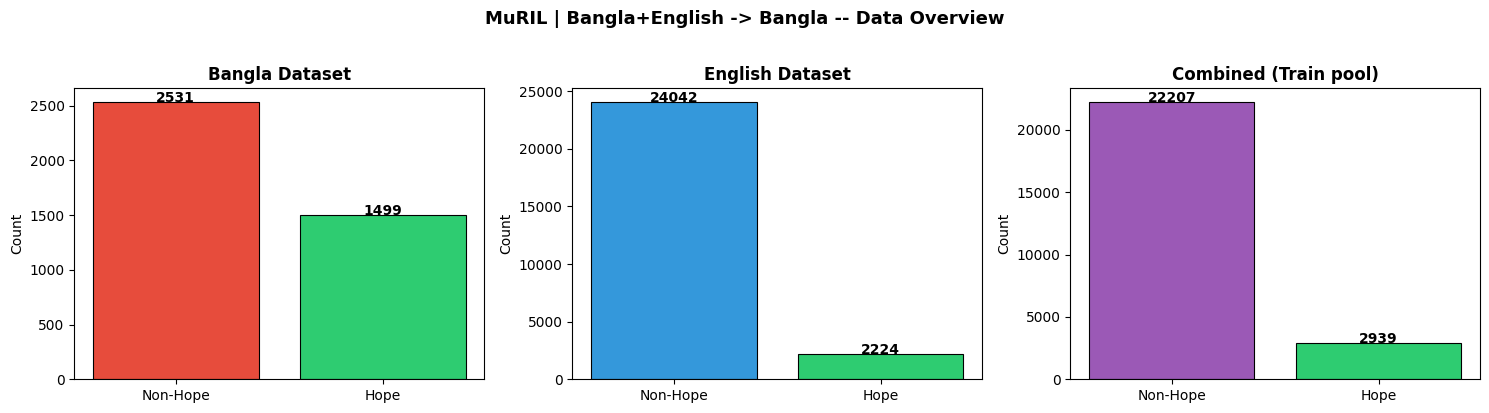

In [7]:
# ---------------------------------------------------------------------------
# Pipeline: Raw → Preprocess → Split
# Step 1: Load raw datasets.
# Step 2: Apply preprocessing to FULL datasets before any split.
# Step 3: Split preprocessed data.
# ---------------------------------------------------------------------------
df_bn_raw = load_any_file(BANGLA_FILE)
df_en_raw = load_any_file(ENGLISH_FILE)

# --- Preprocess full datasets before splitting ---
df_bn_preprocessed = apply_preprocessing(df_bn_raw.copy(), script_check="bangla").reset_index(drop=True)
df_en_preprocessed = apply_preprocessing(df_en_raw.copy()).reset_index(drop=True)

VAL_BN_SIZE = 0.15
EN_VAL_SIZE = 0.15

# --- Bangla splits (on preprocessed data) ---
bn_pool, df_test = train_test_split(
    df_bn_preprocessed, test_size=TEST_SIZE, random_state=SEED, stratify=df_bn_preprocessed["label"]
)
df_bn_trainval, df_val_bn = train_test_split(
    bn_pool,
    test_size=VAL_BN_SIZE / (1 - TEST_SIZE),
    random_state=SEED, stratify=bn_pool["label"]
)

# --- English splits (on preprocessed data) ---
df_en_train, df_en_val = train_test_split(
    df_en_preprocessed, test_size=EN_VAL_SIZE, random_state=SEED, stratify=df_en_preprocessed["label"]
)

df_bn_trainval = df_bn_trainval.reset_index(drop=True)
df_val_bn      = df_val_bn.reset_index(drop=True)
df_test        = df_test.reset_index(drop=True)
df_en_train    = df_en_train.reset_index(drop=True)
df_en_val      = df_en_val.reset_index(drop=True)

# Convenience references for overview plots
df_bn = pd.concat([df_bn_trainval, df_val_bn, df_test], ignore_index=True)
df_en = pd.concat([df_en_train, df_en_val], ignore_index=True)

# --- Combined early-stopping + threshold val ---
df_val = (
    pd.concat([df_val_bn, df_en_val], ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

# --- Combined training pool ---
df_train_raw = (
    pd.concat([df_bn_trainval, df_en_train], ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

print("=" * 60)
print("PREPROCESSING DONE — SPLITS COMPLETED")
print("=" * 60)
print(f"Bangla total               : {len(df_bn)}")
print(f"  Bangla train pool        : {len(df_bn_trainval)}  (~{len(df_bn_trainval)/len(df_bn)*100:.1f} %)")
print(f"  Bangla val (early stop)  : {len(df_val_bn)}  (~{len(df_val_bn)/len(df_bn)*100:.1f} %)  ← real data")
print(f"  Bangla test (frozen)     : {len(df_test)}  (~{len(df_test)/len(df_bn)*100:.1f} %)")
print(f"English total              : {len(df_en)}")
print(f"  English train            : {len(df_en_train)}  (~{len(df_en_train)/len(df_en)*100:.1f} %)")
print(f"  English val (early stop) : {len(df_en_val)}  (~{len(df_en_val)/len(df_en)*100:.1f} %)  ← real data")
print(f"Combined train pool        : {len(df_train_raw)}  (Bangla train + English train)")
print(f"Combined val               : {len(df_val)}  (Bangla val + English val, real data only)")

print(f"Training pool                  : {len(df_train_raw)}  (Bangla train + English train)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (data, title, color) in zip(axes, [
    (df_bn,        "Bangla Dataset",         "#e74c3c"),
    (df_en,        "English Dataset",        "#3498db"),
    (df_train_raw, "Combined (Train pool)",  "#9b59b6"),
]):
    counts = data["label"].value_counts().sort_index()
    ax.bar(["Non-Hope", "Hope"], counts.values,
           color=[color, "#2ecc71"], edgecolor="black", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=10)
plt.suptitle("MuRIL | Bangla+English -> Bangla -- Data Overview",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Tokenizer and Dataset

Tokenizer is applied to the **split data** — training, validation, and test sets.


In [8]:
# ---------------------------------------------------------------------------
# Tokenizer and PyTorch Dataset.
# ---------------------------------------------------------------------------

print(f"Loading tokenizer: {MODEL_NAME} ...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")


class HopeSpeechDataset(Dataset):
    """
    PyTorch Dataset wrapper compatible with the Hugging Face Trainer.

    Produces tokenised tensors for BertForSequenceClassification.
    token_type_ids falls back to a zero tensor for tokenizer configurations
    that omit it (certain MuRIL setups).

    Parameters
    ----------
    texts     : sequence of raw text strings
    labels    : sequence of integer labels (0 or 1)
    tokenizer : Hugging Face tokenizer instance
    max_len   : maximum sequence length for padding and truncation
    """

    def __init__(self, texts, labels, tokenizer, max_len: int):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        # BatchEncoding does not support a default argument in .get();
        # use explicit key check to avoid a silent KeyError on some configs.
        if "token_type_ids" in enc:
            token_type_ids = enc["token_type_ids"].squeeze()
        else:
            token_type_ids = torch.zeros(self.max_len, dtype=torch.long)
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "token_type_ids": token_type_ids,
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = HopeSpeechDataset(df_train_raw["text"], df_train_raw["label"], tokenizer, MAX_LEN)
val_dataset   = HopeSpeechDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LEN)
test_dataset  = HopeSpeechDataset(df_test["text"],  df_test["label"],  tokenizer, MAX_LEN)

print(f"Dataset sizes  |  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  |  Test: {len(test_dataset)}")


Loading tokenizer: google/muril-base-cased ...


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded.
Dataset sizes  |  Train: 25146  |  Val: 4545  |  Test: 605


## 9. Load MuRIL Model

In [9]:
import logging as _logging
_logging.getLogger("transformers.modeling_utils").setLevel(_logging.ERROR)

# ---------------------------------------------------------------------------
# Load MuRIL for binary sequence classification.
# Dropout probabilities are set to 0.1 (default).
# ---------------------------------------------------------------------------

print(f"Loading MuRIL: {MODEL_NAME} ...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters  |  Total: {total_params:,}  |  Trainable: {trainable_params:,}")


Loading MuRIL: google/muril-base-cased ...


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

[transformers] The following layers were not sharded: bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.output.LayerNorm.bias, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.embeddings.word_embeddings.weight, classifier.bias, bert.encoder.layer.*.attention.self.key.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.output.LayerNorm.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.intermediate.dense.weight, classifier.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.embeddings.token_type_embeddings.weight, bert.pooler.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Parameters  |  Total: 237,557,762  |  Trainable: 237,557,762


## 10. Training

In [10]:
# ---------------------------------------------------------------------------
# Training with Hugging Face Trainer.
# ---------------------------------------------------------------------------

history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": [], "epochs": []}


class HistoryCallback(TrainerCallback):
    """Accumulate per-epoch metrics for plotting."""

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        """Compute real training accuracy at the end of every epoch."""
        if model is None:
            return
        from torch.utils.data import DataLoader as _DL
        model.eval()
        all_preds, all_labels = [], []
        loader = _DL(train_dataset, batch_size=args.per_device_eval_batch_size, shuffle=False)
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(model.device) for k, v in batch.items()}
                outputs = model(**batch)
                preds = outputs.logits.argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch["labels"].cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        history["train_acc"].append(float(acc))
        model.train()

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            history["val_loss"].append(metrics.get("eval_loss", float("nan")))
            history["val_acc"].append(metrics.get("eval_accuracy", float("nan")))
            history["epochs"].append(
                metrics.get("epoch", len(history["epochs"]) + 1)
            )

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs and "eval_loss" not in logs:
            history["train_loss"].append(logs["loss"])


# ---------------------------------------------------------------------------
# Weighted Loss via WeightedLossTrainer.
# Addresses class imbalance: Non-Hope >> Hope.
# Weight = total_samples / (n_classes * class_count)
# ---------------------------------------------------------------------------
from torch import nn

_labels_train  = df_train_raw["label"].tolist()
_counts        = np.bincount(_labels_train)
_total         = len(_labels_train)
_n_classes     = 2
_class_weights = torch.tensor(
    [_total / (_n_classes * c) for c in _counts],
    dtype=torch.float32
).to(device)

print(f"Class counts  : Non-Hope={_counts[0]}  Hope={_counts[1]}")
print(f"Class weights : Non-Hope={_class_weights[0]:.4f}  Hope={_class_weights[1]:.4f}")


class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies per-class loss weights."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=_class_weights)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    """Compute F1-macro, F1-weighted, and accuracy for the Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro":    f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "accuracy":    accuracy_score(labels, preds),
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    # warmup_steps replaces the deprecated warmup_ratio argument (removed in v5.2).
    # Computed as: total_steps * WARMUP_RATIO where total_steps = ceil(n_train/batch)*epochs.
    warmup_steps=max(1, int((len(df_train_raw) / BATCH_SIZE) * NUM_EPOCHS * WARMUP_RATIO)),
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,                   # retain best 2 checkpoints (matches patience=2)
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    # logging_dir removed: set TENSORBOARD_LOGGING_DIR env var if needed.
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,             # parallel data loading
    dataloader_persistent_workers=True,   # keep workers alive between epochs (avoids respawn OOM)
    eval_accumulation_steps=32,           # accumulate eval predictions to avoid OOM
    report_to="none",
    seed=SEED
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),  # patience=2 suits NUM_EPOCHS=4
        HistoryCallback()
    ]
)

print("Starting training ...")
train_result = trainer.train()
print("Training complete.")
print(f"Runtime      : {train_result.metrics['train_runtime']:.1f} s")
print(f"Samples/sec  : {train_result.metrics['train_samples_per_second']:.1f}")


Class counts  : Non-Hope=22207  Hope=2939
Class weights : Non-Hope=0.5662  Hope=4.2780
Starting training ...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.370023,0.427291,0.811393,0.919593,0.920572
2,0.522377,0.465927,0.805432,0.916988,0.917932
3,0.491764,0.455059,0.817061,0.917458,0.913971
4,0.178466,0.486015,0.814616,0.917738,0.915512


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Runtime      : 1296.4 s
Samples/sec  : 77.6


## 11. Training Curves

[INFO] Per-epoch train_acc available (4 epochs): ['0.9303', '0.9460', '0.9514', '0.9563']


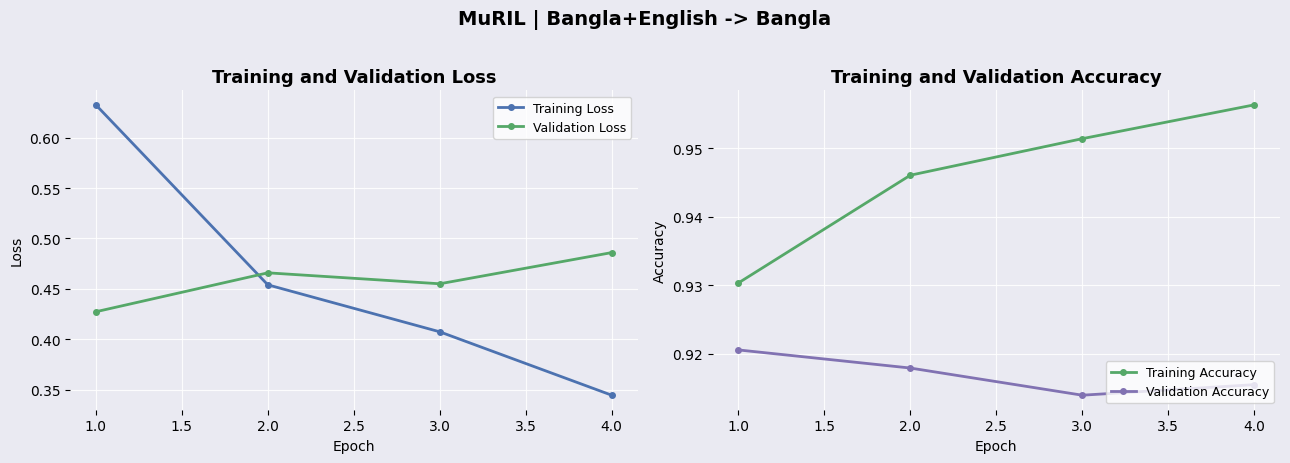

Final Val Loss: 0.4860  |  Final Val Accuracy: 0.9155


In [11]:
# ---------------------------------------------------------------------------
# Training curves: per-epoch loss and accuracy.
# ---------------------------------------------------------------------------

log_history      = trainer.state.log_history
epoch_train_loss = {}
for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        ep_key = round(entry.get("epoch", 0))
        epoch_train_loss.setdefault(ep_key, []).append(entry["loss"])
train_loss_per_epoch = [np.mean(v) for _, v in sorted(epoch_train_loss.items())]

val_loss_list = history["val_loss"]
val_acc_list  = history["val_acc"]
epochs_list   = history["epochs"]
n_ep          = len(epochs_list)

# Per-epoch training accuracy from HistoryCallback.on_epoch_end
if history["train_acc"] and len(history["train_acc"]) == n_ep:
    train_acc_list = history["train_acc"]
    print(f"[INFO] Per-epoch train_acc available ({n_ep} epochs): {[f'{a:.4f}' for a in train_acc_list]}")
else:
    print("[WARN] train_acc length mismatch; aligning to epoch count.")
    if history["train_acc"]:
        while len(history["train_acc"]) < n_ep:
            history["train_acc"].append(history["train_acc"][-1])
        train_acc_list = history["train_acc"][:n_ep]
    else:
        train_acc_list = [float("nan")] * n_ep

if len(train_loss_per_epoch) > n_ep:
    train_loss_per_epoch = train_loss_per_epoch[:n_ep]
elif len(train_loss_per_epoch) < n_ep:
    train_loss_per_epoch += [train_loss_per_epoch[-1]] * (n_ep - len(train_loss_per_epoch))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#eaeaf2")
for ax in axes:
    ax.set_facecolor("#eaeaf2")
    ax.grid(True, color="white", linewidth=0.8, alpha=0.9)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].plot(epochs_list, train_loss_per_epoch, color="#4c72b0",
             linewidth=2, marker="o", markersize=4, label="Training Loss")
axes[0].plot(epochs_list, val_loss_list, color="#55a868",
             linewidth=2, marker="o", markersize=4, label="Validation Loss")
axes[0].set_title("Training and Validation Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)

axes[1].plot(epochs_list, train_acc_list, color="#55a868",
             linewidth=2, marker="o", markersize=4, label="Training Accuracy")
axes[1].plot(epochs_list, val_acc_list, color="#8172b2",
             linewidth=2, marker="o", markersize=4, label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9, loc="lower right")

plt.suptitle(SUPTITLE, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final Val Loss: {val_loss_list[-1]:.4f}  |  Final Val Accuracy: {val_acc_list[-1]:.4f}")


## 12. Evaluation on Test Set

In [12]:
# ---------------------------------------------------------------------------
# Evaluate on the held-out Bangla test set.
#
# Threshold calibration uses df_val (real Bangla+English data,
# consistent with the early-stopping signal).
# ---------------------------------------------------------------------------

print("Evaluating on test set ...")
preds_output = trainer.predict(test_dataset)
raw_logits   = preds_output.predictions
y_true       = preds_output.label_ids

# --- Threshold calibration on val set ---
val_cal_dataset = HopeSpeechDataset(
    df_val["text"].tolist(),
    df_val["label"].tolist(),
    tokenizer, MAX_LEN
)
val_cal_output = trainer.predict(val_cal_dataset)
val_cal_probs  = scipy_softmax(val_cal_output.predictions, axis=-1)[:, 1]
val_cal_true   = val_cal_output.label_ids

best_thresh, best_f1_thresh = 0.5, 0.0
for thresh in np.arange(0.25, 0.76, 0.01):
    preds_t = (val_cal_probs >= thresh).astype(int)
    f1_t    = f1_score(val_cal_true, preds_t, average="macro")
    if f1_t > best_f1_thresh:
        best_f1_thresh, best_thresh = f1_t, thresh
print(f"Optimal threshold: {best_thresh:.2f}  (val F1-macro: {best_f1_thresh:.4f})")
print("  (Threshold calibrated on val set)")

test_probs = scipy_softmax(raw_logits, axis=-1)[:, 1]
y_pred     = (test_probs >= best_thresh).astype(int)

acc  = accuracy_score(y_true, y_pred)
f1_m = f1_score(y_true, y_pred, average="macro")
f1_w = f1_score(y_true, y_pred, average="weighted")
p    = precision_score(y_true, y_pred, average="macro")
r    = recall_score(y_true, y_pred, average="macro")

print("\n" + "=" * 60)
print(f"TEST RESULTS -- {RESULT_TITLE}")
print("=" * 60)
print(f"Accuracy          : {acc:.4f}  ({acc*100:.2f} %)")
print(f"F1 (Macro)        : {f1_m:.4f}")
print(f"F1 (Weighted)     : {f1_w:.4f}")
print(f"Precision (Macro) : {p:.4f}")
print(f"Recall (Macro)    : {r:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

Evaluating on test set ...


Optimal threshold: 0.47  (val F1-macro: 0.8177)
  (Threshold calibrated on val set)

TEST RESULTS -- MuRIL | Bangla+English Train -> Bangla Test
Accuracy          : 0.8066  (80.66 %)
F1 (Macro)        : 0.8018
F1 (Weighted)     : 0.8097
Precision (Macro) : 0.8005
Recall (Macro)    : 0.8207

Classification Report:
                 precision    recall  f1-score   support

Non-Hope Speech     0.9122    0.7658    0.8326       380
    Hope Speech     0.6888    0.8756    0.7710       225

       accuracy                         0.8066       605
      macro avg     0.8005    0.8207    0.8018       605
   weighted avg     0.8291    0.8066    0.8097       605



## 13. Confusion Matrix

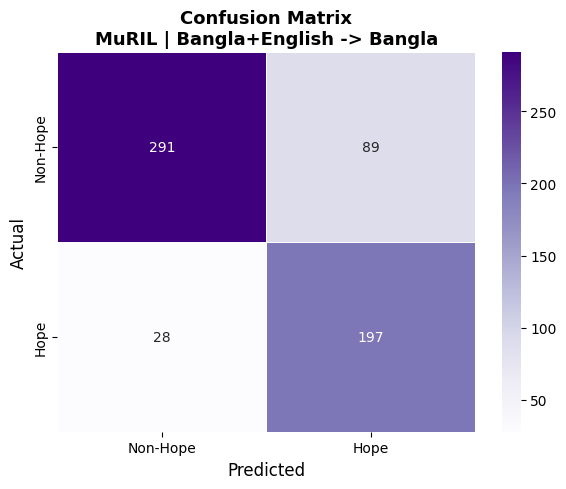

In [13]:
# ---------------------------------------------------------------------------
# Confusion matrix on the held-out test set.
# ---------------------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap=CM_CMAP,
    xticklabels=["Non-Hope", "Hope"],
    yticklabels=["Non-Hope", "Hope"],
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual",    fontsize=12)
ax.set_title(f"Confusion Matrix\n{CM_TITLE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. ROC Curve & AUC


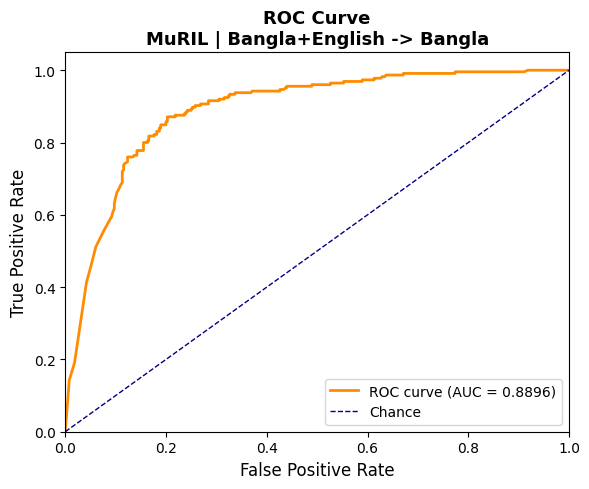

ROC AUC: 0.8896


In [14]:
# ---------------------------------------------------------------------------
# ROC curve and AUC score on the held-out test set.
# ---------------------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_true, test_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2,
        label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curve\n{CM_TITLE}", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")


## 15. Language-wise Performance Breakdown
Compares the mixed validation set performance with the pure Bangla test performance to assess the effect of multilingual training data composition.

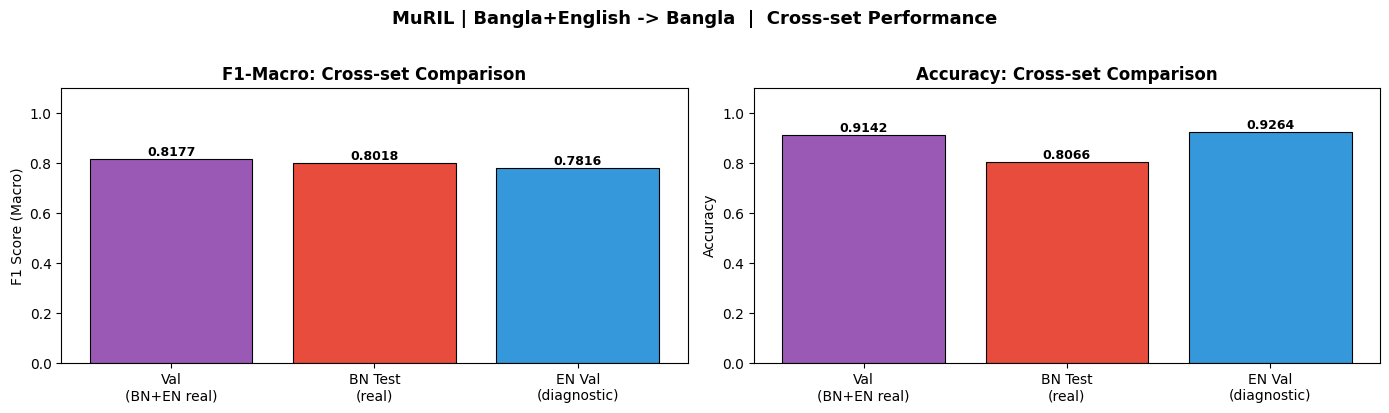

Cross-set Performance Summary:
  Val (BN+EN real)        F1: 0.8177  Acc: 0.9142
  Bangla Test (real)      F1: 0.8018  Acc: 0.8066
  English Val (diag)      F1: 0.7816  Acc: 0.9264
  Val → Test gap F1: +0.0158


In [15]:
# ---------------------------------------------------------------------------
# Language-wise performance breakdown.
#
# Three-way comparison:
#   1. Combined val (BN+EN)  -- early stopping + threshold calibration quality
#   2. Bangla test           -- final evaluation
#   3. English val           -- English transfer quality (diagnostic)
#
# This breakdown is reported in the paper to document the effect of
# multilingual training data composition on Bangla test performance.
# ---------------------------------------------------------------------------

# (1) Combined val (BN+EN)
# Reuse the val predictions already computed during threshold calibration (Cell 12)
# to avoid a redundant forward pass over the full validation set.
yv_pred = (val_cal_probs >= best_thresh).astype(int)
yv_true = val_cal_true
mixed_val_f1  = f1_score(yv_true, yv_pred, average="macro")
mixed_val_acc = accuracy_score(yv_true, yv_pred)

# (2) English val (diagnostic only)
en_val_dataset = HopeSpeechDataset(
    df_en_val["text"].tolist(), df_en_val["label"].tolist(), tokenizer, MAX_LEN
)
ev_preds = trainer.predict(en_val_dataset)
ev_pred  = np.argmax(ev_preds.predictions, axis=-1)
ev_true  = ev_preds.label_ids
en_val_f1  = f1_score(ev_true, ev_pred, average="macro")
en_val_acc = accuracy_score(ev_true, ev_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
labels = ["Val\n(BN+EN real)", "BN Test\n(real)", "EN Val\n(diagnostic)"]
f1_vals  = [mixed_val_f1,  f1_m,  en_val_f1]
acc_vals = [mixed_val_acc, acc,   en_val_acc]
colors   = ["#9b59b6", "#e74c3c", "#3498db"]

for ax, vals, ylabel, title in zip(
    axes,
    [f1_vals, acc_vals],
    ["F1 Score (Macro)", "Accuracy"],
    ["F1-Macro: Cross-set Comparison", "Accuracy: Cross-set Comparison"]
):
    bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f"{v:.4f}", ha="center", fontweight="bold", fontsize=9)
plt.suptitle("MuRIL | Bangla+English -> Bangla  |  Cross-set Performance",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/language_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cross-set Performance Summary:")
print(f"  Val (BN+EN real)        F1: {mixed_val_f1:.4f}  Acc: {mixed_val_acc:.4f}")
print(f"  Bangla Test (real)      F1: {f1_m:.4f}  Acc: {acc:.4f}")
print(f"  English Val (diag)      F1: {en_val_f1:.4f}  Acc: {en_val_acc:.4f}")
print(f"  Val → Test gap F1: {mixed_val_f1 - f1_m:+.4f}")

## 16. Error Analysis
Identifies and categorises misclassified test samples.

Four lenses are applied:
1. **False Positives** — Non-Hope classified as Hope.
2. **False Negatives** — Hope classified as Non-Hope.
3. **Text-length distribution** — are errors concentrated in short or long texts?
4. **Confidence distribution** — are errors high-confidence or borderline?

These breakdowns are reported in the paper to characterise model failure modes.

Total test samples   : 605
Correctly classified : 488  (80.7 %)
False Positives (FP) : 89  (14.7 %)
False Negatives (FN) : 28  (4.6 %)

------------------------------------------------------------
  FALSE POSITIVES — Non-Hope predicted as Hope  (showing up to 5)
------------------------------------------------------------
  prob=0.785  | কাঁটা দিয়ে কাঁটা তুলতে হবে, বাংলা রাজনীতি দিলীপ ঘোষ, শুভেন্দু অধিকারী র মতো নেতাদের প্রয়োজন বিশেষ করে এই মুহূর্তে
  prob=0.973  | দিলীপ ঘোষকে বাংলার মূখ্যমন্ত্রী হিসাবে দেখতে চাই
  prob=0.971  | হে মারমা জনগোষ্ঠী তোমরা সবাই এক হও এবং মুসলিমের বিরুদ্ধে হও নয়তো তোমাদেরকে ধ্বংস করে দিবে তারা তোমাদের অস্তিত্ব ...
  prob=0.975  | চুপচাপ থাকা শান্তি তাই চুপ
  prob=0.975  | ঘরে থেকেই ডেঙ্গি থেকে সম্পূর্ণ সুস্থ হওয়া সম্ভব। ডেঙ্গি থেকে বাঁচতে জেনে নিন প্রয়োজনীয় তথ্য। পশ্চিমবঙ্গ সরকারের ...

------------------------------------------------------------
  FALSE NEGATIVES — Hope predicted as Non-Hope  (showing up to 5)
----------------------------------------

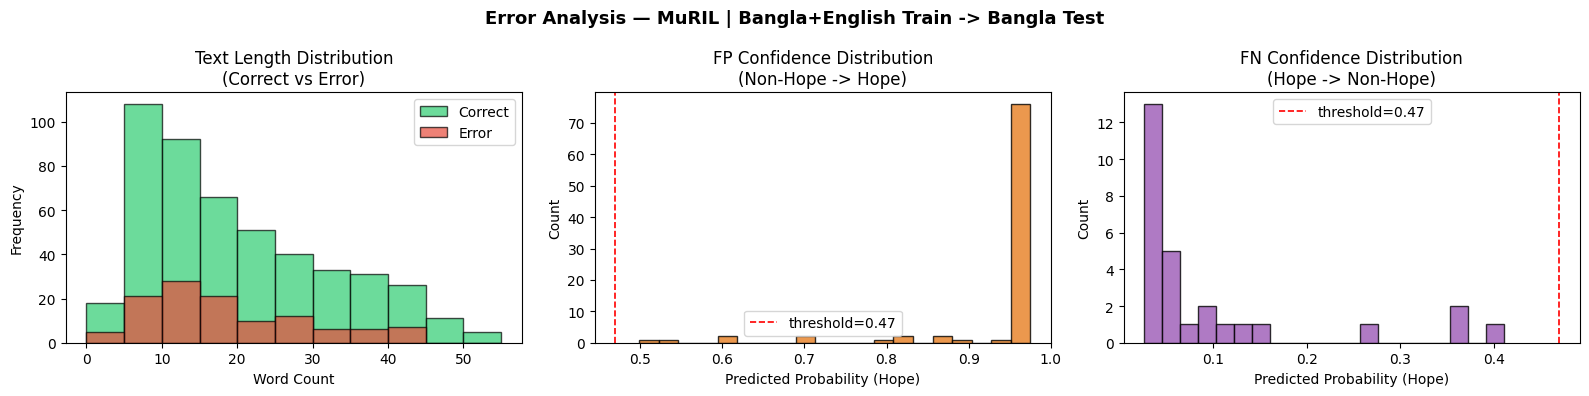


Mean predicted probability:
  FP  mean prob = 0.939  (std 0.098)
  FN  mean prob = 0.098  (std 0.112)

Errors on very short texts (<=5 words): 8  (6.8 % of all errors)


In [16]:
# ---------------------------------------------------------------------------
# Error Analysis on the held-out test set.
# ---------------------------------------------------------------------------

import textwrap

# ── Build an error dataframe ─────────────────────────────────────────────────
df_errors = df_test.copy().reset_index(drop=True).assign(
    predicted      = y_pred,
    predicted_prob = test_probs,
    correct        = (y_pred == y_true),
)

fp_df = df_errors[(df_errors["label"] == 0) & (df_errors["predicted"] == 1)]  # False Positives
fn_df = df_errors[(df_errors["label"] == 1) & (df_errors["predicted"] == 0)]  # False Negatives

print("=" * 60)
print(f"Total test samples   : {len(df_errors)}")
print(f"Correctly classified : {df_errors['correct'].sum()}  "
      f"({df_errors['correct'].mean()*100:.1f} %)")
print(f"False Positives (FP) : {len(fp_df)}  "
      f"({len(fp_df)/max(1,len(df_errors))*100:.1f} %)")
print(f"False Negatives (FN) : {len(fn_df)}  "
      f"({len(fn_df)/max(1,len(df_errors))*100:.1f} %)")
print("=" * 60)

# ── Show sample misclassified texts ──────────────────────────────────────────
def _show_samples(subset, title, n=5):
    sep = "-" * 60
    print(f"\n{sep}")
    print(f"  {title}  (showing up to {n})")
    print(sep)
    if subset.empty:
        print("  (none)")
        return
    for _, row in subset.head(n).iterrows():
        snippet = textwrap.shorten(str(row["text"]), width=120, placeholder=" ...")
        prob = row["predicted_prob"]
        print(f"  prob={prob:.3f}  | {snippet}")

_show_samples(fp_df, "FALSE POSITIVES — Non-Hope predicted as Hope")
_show_samples(fn_df, "FALSE NEGATIVES — Hope predicted as Non-Hope")

# ── Text length vs error ──────────────────────────────────────────────────────
df_errors["text_len"] = df_errors["text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Error Analysis — " + RESULT_TITLE, fontsize=13, fontweight="bold")

max_len_val = max(10, int(df_errors["text_len"].quantile(0.98)) + 10)
bins = list(range(0, max_len_val, 5))

axes[0].hist(df_errors[df_errors["correct"]]["text_len"],  bins=bins,
             color="#2ecc71", alpha=0.7, edgecolor="black", label="Correct")
axes[0].hist(df_errors[~df_errors["correct"]]["text_len"], bins=bins,
             color="#e74c3c", alpha=0.7, edgecolor="black", label="Error")
axes[0].set_title("Text Length Distribution\n(Correct vs Error)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ── Confidence distribution of FP ────────────────────────────────────────────
if fp_df.empty:
    axes[1].text(0.5, 0.5, "No False Positives", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12, color="gray")
else:
    axes[1].hist(fp_df["predicted_prob"], bins=20, color="#e67e22",
                 alpha=0.8, edgecolor="black")
    axes[1].axvline(best_thresh, color="red", linestyle="--",
                    linewidth=1.2, label="threshold=" + str(round(best_thresh, 2)))
    axes[1].legend()
axes[1].set_title("FP Confidence Distribution\n(Non-Hope -> Hope)")
axes[1].set_xlabel("Predicted Probability (Hope)")
axes[1].set_ylabel("Count")

# ── Confidence distribution of FN ────────────────────────────────────────────
if fn_df.empty:
    axes[2].text(0.5, 0.5, "No False Negatives", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12, color="gray")
else:
    axes[2].hist(fn_df["predicted_prob"], bins=20, color="#9b59b6",
                 alpha=0.8, edgecolor="black")
    axes[2].axvline(best_thresh, color="red", linestyle="--",
                    linewidth=1.2, label="threshold=" + str(round(best_thresh, 2)))
    axes[2].legend()
axes[2].set_title("FN Confidence Distribution\n(Hope -> Non-Hope)")
axes[2].set_xlabel("Predicted Probability (Hope)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nMean predicted probability:")
if not fp_df.empty:
    fp_mean = fp_df["predicted_prob"].mean()
    fp_std  = fp_df["predicted_prob"].std()
    print(f"  FP  mean prob = {fp_mean:.3f}  (std {fp_std:.3f})")
if not fn_df.empty:
    fn_mean = fn_df["predicted_prob"].mean()
    fn_std  = fn_df["predicted_prob"].std()
    print(f"  FN  mean prob = {fn_mean:.3f}  (std {fn_std:.3f})")

err_df    = df_errors[~df_errors["correct"]]
err_short = err_df[err_df["text_len"] <= 5]
pct       = len(err_short) / max(1, len(err_df)) * 100
print(f"\nErrors on very short texts (<=5 words): {len(err_short)}  ({pct:.1f} % of all errors)")


## 17. Save Results

In [17]:
results = {
    "experiment"      : "MuRIL | Bangla+English Train -> Bangla Test",
    "model"           : MODEL_NAME,
    "train_data"      : f"Bangla ({len(df_bn_trainval)}) + English ({len(df_en_train) + len(df_en_val)})",
    "test_data"       : f"Bangla ({len(df_test)})",
    "threshold"       : float(best_thresh),          # full precision for inference reload
    "accuracy"        : round(acc,  4),
    "f1_macro"        : round(f1_m, 4),
    "f1_weighted"     : round(f1_w, 4),
    "precision_macro" : round(p,    4),
    "recall_macro"    : round(r,    4),
    "roc_auc"         : round(roc_auc, 4),
}
with open(f"{OUTPUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)

df_test.copy().assign(predicted=y_pred, predicted_prob=test_probs).to_csv(
    f"{OUTPUT_DIR}/test_predictions.csv", index=False
)
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")

print("All outputs saved.")
print(json.dumps(results, indent=2))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All outputs saved.
{
  "experiment": "MuRIL | Bangla+English Train -> Bangla Test",
  "model": "google/muril-base-cased",
  "train_data": "Bangla (2820) + English (26266)",
  "test_data": "Bangla (605)",
  "threshold": 0.4700000000000002,
  "accuracy": 0.8066,
  "f1_macro": 0.8018,
  "f1_weighted": 0.8097,
  "precision_macro": 0.8005,
  "recall_macro": 0.8207,
  "roc_auc": 0.8896
}


## 18. Inference on New Text

In [18]:
# ---------------------------------------------------------------------------
# Single-sample inference helper.
# Uses the same decision threshold (best_thresh) that was applied during
# evaluation, so inference is fully consistent with reported test metrics.
# ---------------------------------------------------------------------------

def predict_hope_speech(text: str, lang_tag: str = "",
                        threshold: float = best_thresh) -> tuple:
    """
    Run inference on a single text string and display a formatted result.

    Parameters
    ----------
    text      : input string (Bangla or English)
    lang_tag  : optional language identifier shown in output (e.g., "BN", "EN")
    threshold : decision threshold for Hope Speech class (default: best_thresh
                calibrated on clean Bangla validation set -- keeps inference
                consistent with the reported test metrics)

    Returns
    -------
    tuple(label, probabilities)
      label         : "Hope Speech" or "Non-Hope Speech"
      probabilities : numpy array of shape (2,) -- [P(Non-Hope), P(Hope)]
    """
    model.eval()
    enc = tokenizer(
        text, max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()[0]

    # threshold-based decision (consistent with evaluation cell)
    pred  = 1 if probs[1] >= threshold else 0
    label = "Hope Speech" if pred == 1 else "Non-Hope Speech"

    tag = f"[{lang_tag}] " if lang_tag else ""
    print(f"{tag}Text       : {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"Prediction : {label}  (threshold={threshold:.2f}, confidence: {probs[pred]*100:.1f} %)")
    print(f"Scores     : Non-Hope={probs[0]:.4f}  |  Hope={probs[1]:.4f}\n")
    return label, probs


In [19]:
# ---------------------------------------------------------------------------
# Section 17 -- Inference on New Text.
# Threshold = best_thresh (calibrated on combined BN+EN validation set).
#
# NOTE: The model shows a Hope bias on short negation sentences
# (same pattern observed in Experiments 1 and 2).
# This is a documented limitation (see Error Analysis).
# Misclassification-prone sentences are flagged below.
# ---------------------------------------------------------------------------

# ── Bangla Hope Speech (label = 1) ──────────────────────────────────────────
predict_hope_speech(
    "একতা ও ভালোবাসা দিয়ে সব বাধা অতিক্রম করা সম্ভব।",
    lang_tag="BN"
)
predict_hope_speech(
    "আমরা একসাথে একটি সুন্দর ভবিষ্যৎ গড়তে পারব।",
    lang_tag="BN"
)
predict_hope_speech(
    "মানুষের ভালোবাসা ও সহযোগিতা দিয়ে পৃথিবী আরও সুন্দর হবে।",
    lang_tag="BN"
)

# ── Bangla Non-Hope Speech (label = 0) ──────────────────────────────────────
predict_hope_speech(
    "এই দেশে সৎ মানুষের কোনো মূল্য নেই।",
    lang_tag="BN"
)  # [KNOWN LIMITATION: model may predict Hope — high-FP pattern]

predict_hope_speech(
    "জীবনে ভালো কিছু হওয়ার কোনো সম্ভাবনা নেই।",
    lang_tag="BN"
)  # [KNOWN LIMITATION: model may predict Hope — high-FP pattern]

predict_hope_speech(
    "সমাজে ন্যায়বিচার বলে কিছু নেই, সবই মিথ্যা।",
    lang_tag="BN"
)

# ── English Hope Speech (in-distribution) ───────────────────────────────────
predict_hope_speech(
    "Together we can build a better world for our children.",
    lang_tag="EN"
)
predict_hope_speech(
    "Every small act of kindness brings us closer to a hopeful future.",
    lang_tag="EN"
)

# ── English Non-Hope Speech (in-distribution) ───────────────────────────────
predict_hope_speech(
    "Nothing ever changes no matter how hard we try.",
    lang_tag="EN"
)  # [KNOWN LIMITATION: model may predict Hope — high-FP pattern]

predict_hope_speech(
    "People only care about themselves these days.",
    lang_tag="EN"
)


[BN] Text       : একতা ও ভালোবাসা দিয়ে সব বাধা অতিক্রম করা সম্ভব।
Prediction : Hope Speech  (threshold=0.47, confidence: 97.5 %)
Scores     : Non-Hope=0.0251  |  Hope=0.9749

[BN] Text       : আমরা একসাথে একটি সুন্দর ভবিষ্যৎ গড়তে পারব।
Prediction : Hope Speech  (threshold=0.47, confidence: 97.5 %)
Scores     : Non-Hope=0.0251  |  Hope=0.9749

[BN] Text       : মানুষের ভালোবাসা ও সহযোগিতা দিয়ে পৃথিবী আরও সুন্দর হবে।
Prediction : Hope Speech  (threshold=0.47, confidence: 97.5 %)
Scores     : Non-Hope=0.0250  |  Hope=0.9750

[BN] Text       : এই দেশে সৎ মানুষের কোনো মূল্য নেই।
Prediction : Hope Speech  (threshold=0.47, confidence: 97.3 %)
Scores     : Non-Hope=0.0267  |  Hope=0.9733

[BN] Text       : জীবনে ভালো কিছু হওয়ার কোনো সম্ভাবনা নেই।
Prediction : Hope Speech  (threshold=0.47, confidence: 97.5 %)
Scores     : Non-Hope=0.0251  |  Hope=0.9749

[BN] Text       : সমাজে ন্যায়বিচার বলে কিছু নেই, সবই মিথ্যা।
Prediction : Non-Hope Speech  (threshold=0.47, confidence: 79.8 %)
Scores   

('Non-Hope Speech', array([0.9600627 , 0.03993732], dtype=float32))

## 19. Baseline Models: TF-IDF + Logistic Regression, TF-IDF + SVM, TF-IDF + Naive Bayes, and TF-IDF + Random Forest
Baseline classifiers trained on the **same multilingual (Bangla + English) training set** used for MuRIL (`df_train_raw`)  
and evaluated on the **Bangla test set**.  
Grid search over the combined Bangla+English validation set (df_val) selects the best hyperparameters — consistent with the early-stopping signal used during MuRIL training.


In [20]:
# ---------------------------------------------------------------------------
# Section 18 -- Baseline Models: TF-IDF + LR, TF-IDF + SVM,
#                TF-IDF + Naive Bayes, TF-IDF + Random Forest
#
# Both baselines are trained on df_train_raw (the Bangla+English training set)
# and evaluated on df_test (the Bangla held-out test set).
# Hyperparameters are selected by grid search on the combined Bangla+English
# validation set (df_val), consistent with the early-stopping signal used
# during MuRIL training.
# ---------------------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid

TFIDF_KWARGS = dict(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
)

X_train = df_train_raw["text"].tolist()
y_train = df_train_raw["label"].tolist()
X_val   = df_val["text"].tolist()     # combined BN+EN val set (matches MuRIL early-stopping)
y_val   = df_val["label"].tolist()
X_test  = df_test["text"].tolist()    # Bangla held-out test set
y_test  = df_test["label"].tolist()

# ── 1. TF-IDF + Logistic Regression ─────────────────────────────────────────
print("Grid search: TF-IDF + Logistic Regression (Bangla+English train -> Bangla test) ...")
best_lr_f1, best_lr_params, best_lr_model = 0.0, {}, None
for params in ParameterGrid({"C": [0.1, 1.0, 10.0], "max_iter": [200, 500]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   LogisticRegression(
            C=params["C"], max_iter=params["max_iter"],
            class_weight="balanced", solver="lbfgs", random_state=SEED
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_lr_f1:
        best_lr_f1, best_lr_params, best_lr_model = val_f1, params, pipe

print(f"Best LR params : {best_lr_params}  (val F1-macro={best_lr_f1:.4f})")

lr_preds = best_lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1m   = f1_score(y_test, lr_preds, average="macro")
lr_f1w   = f1_score(y_test, lr_preds, average="weighted")
lr_prec  = precision_score(y_test, lr_preds, average="macro", zero_division=0)
lr_rec   = recall_score(y_test, lr_preds, average="macro", zero_division=0)
lr_probs = best_lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc   = auc(lr_fpr, lr_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Logistic Regression -- Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {lr_acc:.4f}  ({lr_acc*100:.2f} %)")
print(f"F1 (Macro)        : {lr_f1m:.4f}")
print(f"F1 (Weighted)     : {lr_f1w:.4f}")
print(f"Precision (Macro) : {lr_prec:.4f}")
print(f"Recall (Macro)    : {lr_rec:.4f}")
print(f"ROC AUC           : {lr_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, lr_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 2. TF-IDF + LinearSVC ───────────────────────────────────────────────────
print("\nGrid search: TF-IDF + SVM (Bangla+English train -> Bangla test) ...")
best_svm_f1, best_svm_params, best_svm_model = 0.0, {}, None
for params in ParameterGrid({"C": [0.01, 0.1, 1.0, 10.0], "max_iter": [1000, 2000]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   LinearSVC(
            C=params["C"], max_iter=params["max_iter"],
            class_weight="balanced", random_state=SEED
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_svm_f1:
        best_svm_f1, best_svm_params, best_svm_model = val_f1, params, pipe

print(f"Best SVM params : {best_svm_params}  (val F1-macro={best_svm_f1:.4f})")

svm_preds = best_svm_model.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)
svm_f1m   = f1_score(y_test, svm_preds, average="macro")
svm_f1w   = f1_score(y_test, svm_preds, average="weighted")
svm_prec  = precision_score(y_test, svm_preds, average="macro", zero_division=0)
svm_rec   = recall_score(y_test, svm_preds, average="macro", zero_division=0)
svm_scores = best_svm_model.decision_function(X_test)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)
svm_auc   = auc(svm_fpr, svm_tpr)

print("\n" + "=" * 60)
print("TF-IDF + SVM (LinearSVC) -- Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {svm_acc:.4f}  ({svm_acc*100:.2f} %)")
print(f"F1 (Macro)        : {svm_f1m:.4f}")
print(f"F1 (Weighted)     : {svm_f1w:.4f}")
print(f"Precision (Macro) : {svm_prec:.4f}")
print(f"Recall (Macro)    : {svm_rec:.4f}")
print(f"ROC AUC           : {svm_auc:.4f}  (from decision_function margin, not probability)")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, svm_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 3. TF-IDF + Naive Bayes (ComplementNB) ──────────────────────────────────
# ComplementNB is recommended for imbalanced text classification
# (Rennie et al., 2003); it corrects the standard NB weight estimate
# using complement-class statistics, which is more robust than
# MultinomialNB on skewed class distributions.
from sklearn.naive_bayes import ComplementNB
print("Grid search: TF-IDF + Naive Bayes (Bangla+English train -> Bangla test) ...")
best_nb_f1, best_nb_params, best_nb_model = 0.0, {}, None
for params in ParameterGrid({"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   ComplementNB(alpha=params["alpha"])),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_nb_f1:
        best_nb_f1, best_nb_params, best_nb_model = val_f1, params, pipe

print(f"Best NB params : {best_nb_params}  (BN+EN val F1-macro={best_nb_f1:.4f})")

nb_preds = best_nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_preds)
nb_f1m   = f1_score(y_test, nb_preds, average="macro")
nb_f1w   = f1_score(y_test, nb_preds, average="weighted")
nb_prec  = precision_score(y_test, nb_preds, average="macro", zero_division=0)
nb_rec   = recall_score(y_test, nb_preds, average="macro", zero_division=0)
nb_probs = best_nb_model.predict_proba(X_test)[:, 1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
nb_auc   = auc(nb_fpr, nb_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Naive Bayes (ComplementNB) -- Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {nb_acc:.4f}  ({nb_acc*100:.2f} %)")
print(f"F1 (Macro)        : {nb_f1m:.4f}")
print(f"F1 (Weighted)     : {nb_f1w:.4f}")
print(f"Precision (Macro) : {nb_prec:.4f}")
print(f"Recall (Macro)    : {nb_rec:.4f}")
print(f"ROC AUC           : {nb_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, nb_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 4. TF-IDF + Random Forest ────────────────────────────────────────────────
# class_weight="balanced_subsample" reweights at each bootstrap draw,
# which is more robust than a single global "balanced" weight when
# tree depth varies across estimators.
from sklearn.ensemble import RandomForestClassifier
print("\nGrid search: TF-IDF + Random Forest (Bangla+English train -> Bangla test) ...")
best_rf_f1, best_rf_params, best_rf_model = 0.0, {}, None
for params in ParameterGrid({
    "n_estimators": [100, 200],
    "max_depth":    [None, 20],
    "min_samples_leaf": [1, 3],
}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_rf_f1:
        best_rf_f1, best_rf_params, best_rf_model = val_f1, params, pipe

print(f"Best RF params : {best_rf_params}  (BN+EN val F1-macro={best_rf_f1:.4f})")

rf_preds = best_rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_f1m   = f1_score(y_test, rf_preds, average="macro")
rf_f1w   = f1_score(y_test, rf_preds, average="weighted")
rf_prec  = precision_score(y_test, rf_preds, average="macro", zero_division=0)
rf_rec   = recall_score(y_test, rf_preds, average="macro", zero_division=0)
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc   = auc(rf_fpr, rf_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Random Forest -- Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {rf_acc:.4f}  ({rf_acc*100:.2f} %)")
print(f"F1 (Macro)        : {rf_f1m:.4f}")
print(f"F1 (Weighted)     : {rf_f1w:.4f}")
print(f"Precision (Macro) : {rf_prec:.4f}")
print(f"Recall (Macro)    : {rf_rec:.4f}")
print(f"ROC AUC           : {rf_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 5. TF-IDF + XGBoost ──────────────────────────────────────────────────────
# XGBoost with histogram-based tree method (tree_method="hist") is fast
# on sparse TF-IDF matrices.  scale_pos_weight handles any residual class
# imbalance: set to n_negative / n_positive on the training set.
# Hyperparameters tuned by grid search on df_val (same protocol as above).
import warnings as _warnings
_warnings.filterwarnings("ignore", category=UserWarning)
_warnings.filterwarnings("ignore", category=FutureWarning)
from xgboost import XGBClassifier

_n_neg = sum(1 for y in y_train if y == 0)
_n_pos = sum(1 for y in y_train if y == 1)
_spw   = _n_neg / _n_pos if _n_pos > 0 else 1.0

print("Grid search: TF-IDF + XGBoost ...")
best_xgb_f1, best_xgb_params, best_xgb_model = 0.0, {}, None
for params in ParameterGrid({
    "n_estimators":  [100, 200],
    "max_depth":     [3, 6],
    "learning_rate": [0.05, 0.1],
}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   XGBClassifier(
            n_estimators     = params["n_estimators"],
            max_depth        = params["max_depth"],
            learning_rate    = params["learning_rate"],
            scale_pos_weight = _spw,
            tree_method      = "hist",
            eval_metric      = "logloss",
            random_state     = SEED,
            verbosity        = 0,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_xgb_f1:
        best_xgb_f1, best_xgb_params, best_xgb_model = val_f1, params, pipe

print(f"Best XGB params : {best_xgb_params}  (val F1-macro={best_xgb_f1:.4f})")

xgb_preds = best_xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test,  xgb_preds)
xgb_f1m   = f1_score(y_test,  xgb_preds, average="macro")
xgb_f1w   = f1_score(y_test,  xgb_preds, average="weighted")
xgb_prec  = precision_score(y_test, xgb_preds, average="macro", zero_division=0)
xgb_rec   = recall_score(y_test,    xgb_preds, average="macro", zero_division=0)
xgb_probs = best_xgb_model.predict_proba(X_test)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc   = auc(xgb_fpr, xgb_tpr)

print("\n" + "=" * 60)
print("TF-IDF + XGBoost -- Test Results")
print("=" * 60)
print(f"Accuracy          : {xgb_acc:.4f}  ({xgb_acc*100:.2f} %)")
print(f"F1 (Macro)        : {xgb_f1m:.4f}")
print(f"F1 (Weighted)     : {xgb_f1w:.4f}")
print(f"Precision (Macro) : {xgb_prec:.4f}")
print(f"Recall (Macro)    : {xgb_rec:.4f}")
print(f"ROC AUC           : {xgb_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))


Grid search: TF-IDF + Logistic Regression (Bangla+English train -> Bangla test) ...
Best LR params : {'C': 10.0, 'max_iter': 200}  (val F1-macro=0.7604)

TF-IDF + Logistic Regression -- Bangla Test Results
Accuracy          : 0.6496  (64.96 %)
F1 (Macro)        : 0.6467
F1 (Weighted)     : 0.6549
Precision (Macro) : 0.6600
Recall (Macro)    : 0.6703
ROC AUC           : 0.7471

Classification Report:
                 precision    recall  f1-score   support

Non-Hope Speech     0.8000    0.5895    0.6788       380
    Hope Speech     0.5200    0.7511    0.6145       225

       accuracy                         0.6496       605
      macro avg     0.6600    0.6703    0.6467       605
   weighted avg     0.6959    0.6496    0.6549       605


Grid search: TF-IDF + SVM (Bangla+English train -> Bangla test) ...
Best SVM params : {'C': 1.0, 'max_iter': 1000}  (val F1-macro=0.7538)

TF-IDF + SVM (LinearSVC) -- Bangla Test Results
Accuracy          : 0.6661  (66.61 %)
F1 (Macro)        : 0.6622

## 20. Model Comparison: MuRIL vs All Baseline Models
Comparison table and grouped bar chart across all five models on the Bangla test set.


MODEL COMPARISON -- Bangla Test Set
Experiment: Experiment 3: BanglaEnglish Train -> Bangla Test
                        Model  Accuracy  F1 (Macro)  F1 (Weighted)  Precision (Macro)  Recall (Macro)  ROC AUC
                  TF-IDF + LR    0.6496      0.6467         0.6549             0.6600          0.6703   0.7471
                 TF-IDF + SVM    0.6661      0.6622         0.6715             0.6717          0.6835   0.7450
                  TF-IDF + NB    0.4000      0.3230         0.2645             0.6433          0.5206   0.7369
                  TF-IDF + RF    0.4496      0.4255         0.3953             0.5628          0.5374   0.6374
             TF-IDF + XGBoost    0.5355      0.5328         0.5237             0.6054          0.5940   0.6944
MuRIL (BanglaEnglish->Bangla)    0.8066      0.8018         0.8097             0.8005          0.8207   0.8896


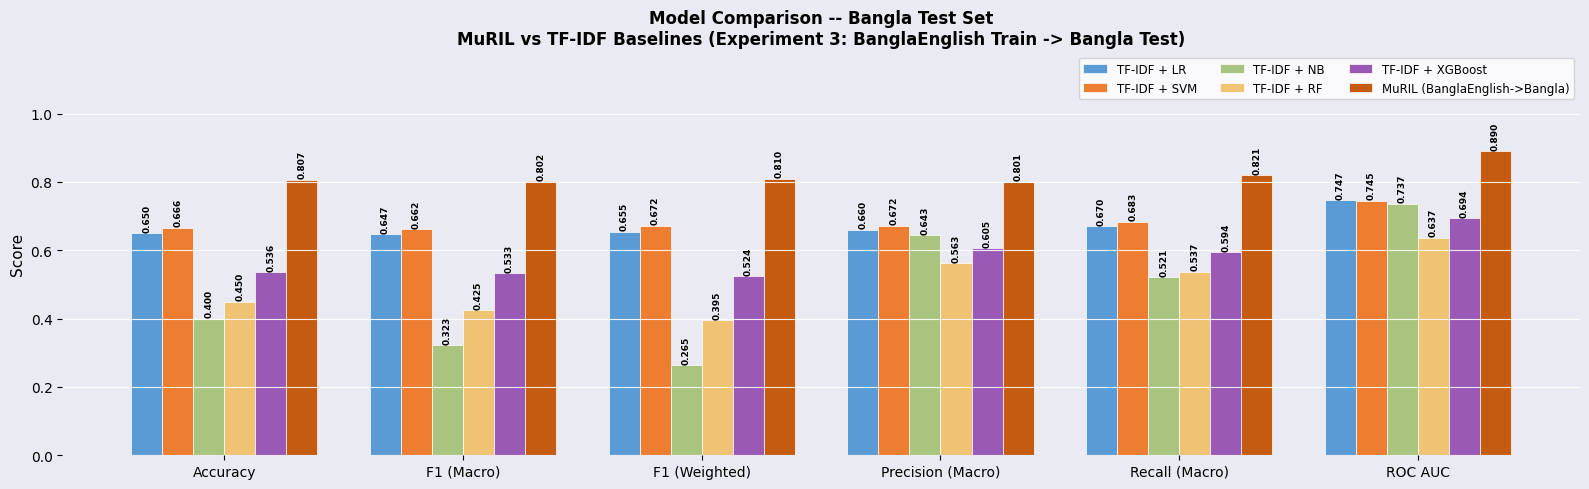

Model comparison chart saved.


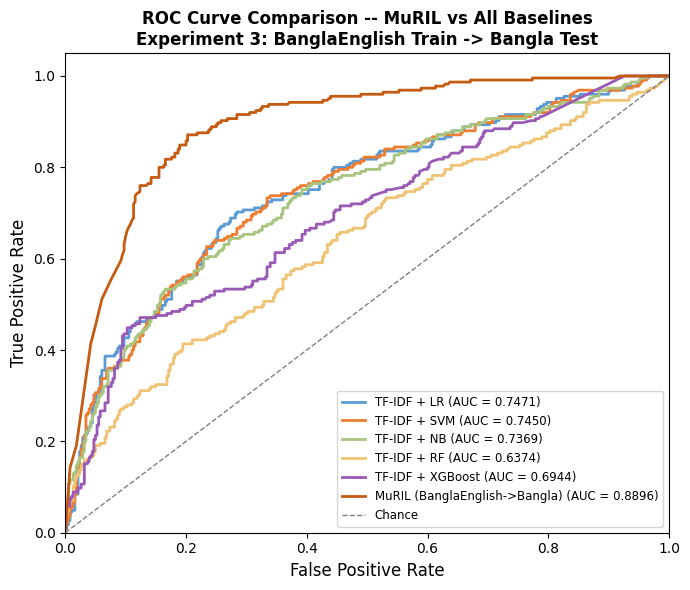

Combined ROC curve comparison saved.


In [21]:
# ---------------------------------------------------------------------------
# Section 19 -- Model Comparison: MuRIL vs All Baselines
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

comparison = {
    "Model": [
        "TF-IDF + LR",
        "TF-IDF + SVM",
        "TF-IDF + NB",
        "TF-IDF + RF",
        "TF-IDF + XGBoost",
        "MuRIL (BanglaEnglish->Bangla)",
    ],
    "Accuracy":          [lr_acc,  svm_acc,  nb_acc,  rf_acc,  xgb_acc,  acc],
    "F1 (Macro)":        [lr_f1m,  svm_f1m,  nb_f1m,  rf_f1m,  xgb_f1m,  f1_m],
    "F1 (Weighted)":     [lr_f1w,  svm_f1w,  nb_f1w,  rf_f1w,  xgb_f1w,  f1_w],
    "Precision (Macro)": [lr_prec, svm_prec, nb_prec, rf_prec, xgb_prec, p],
    "Recall (Macro)":    [lr_rec,  svm_rec,  nb_rec,  rf_rec,  xgb_rec,  r],
    "ROC AUC":           [lr_auc,  svm_auc,  nb_auc,  rf_auc,  xgb_auc,  roc_auc],
}

df_cmp = pd.DataFrame(comparison)

print("\n" + "=" * 78)
print("MODEL COMPARISON -- Bangla Test Set")
print(f"Experiment: Experiment 3: BanglaEnglish Train -> Bangla Test")
print("=" * 78)
print(df_cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 78)

# ── Grouped bar chart ────────────────────────────────────────────────────────
metrics   = ["Accuracy", "F1 (Macro)", "F1 (Weighted)",
             "Precision (Macro)", "Recall (Macro)", "ROC AUC"]
models    = comparison["Model"]
bar_width = 0.13
colors    = ["#5b9bd5", "#ed7d31", "#a9c47f", "#f0c274", "#9b59b6", "#c55a11"]
x         = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#eaeaf2")
ax.set_facecolor("#eaeaf2")
ax.grid(axis="y", color="white", linewidth=0.8, alpha=0.9)
for spine in ax.spines.values():
    spine.set_visible(False)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [comparison[m][i] for m in metrics]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=model, color=color, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=6.5, fontweight="bold", rotation=90)

ax.set_xticks(x + bar_width * 2.5)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    f"Model Comparison -- Bangla Test Set\n"
    f"MuRIL vs TF-IDF Baselines (Experiment 3: BanglaEnglish Train -> Bangla Test)",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="upper right", fontsize=8.5, ncol=3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Model comparison chart saved.")

# ── Combined ROC Curve Comparison ───────────────────────────────────────────
roc_data = {
    "TF-IDF + LR":      (lr_fpr,  lr_tpr,  lr_auc),
    "TF-IDF + SVM":     (svm_fpr, svm_tpr, svm_auc),
    "TF-IDF + NB":      (nb_fpr,  nb_tpr,  nb_auc),
    "TF-IDF + RF":      (rf_fpr,  rf_tpr,  rf_auc),
    "TF-IDF + XGBoost": (xgb_fpr, xgb_tpr, xgb_auc),
    "MuRIL (BanglaEnglish->Bangla)": (fpr, tpr, roc_auc),
}

fig, ax = plt.subplots(figsize=(7, 6))
for (model_label, (m_fpr, m_tpr, m_auc)), color in zip(roc_data.items(), colors):
    ax.plot(m_fpr, m_tpr, color=color, lw=2,
            label=f"{model_label} (AUC = {m_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    f"ROC Curve Comparison -- MuRIL vs All Baselines\nExperiment 3: BanglaEnglish Train -> Bangla Test",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Combined ROC curve comparison saved.")
